In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00



image 1/1 /content/street.webp: 640x384 11 persons, 97.9ms
Speed: 1.3ms preprocess, 97.9ms inference, 18.9ms postprocess per image at shape (1, 3, 640, 384)
person: 0.86 at [134, 423, 188, 590]
person: 0.85 at [212, 513, 276, 704]
person: 0.82 at [1, 538, 72, 728]
person: 0.78 at [95, 608, 165, 728]
person: 0.78 at [283, 481, 342, 693]
person: 0.76 at [179, 357, 220, 476]
person: 0.70 at [45, 491, 101, 702]
person: 0.67 at [302, 580, 382, 728]
person: 0.67 at [163, 220, 196, 308]
person: 0.59 at [216, 248, 250, 346]
person: 0.53 at [32, 262, 68, 365]


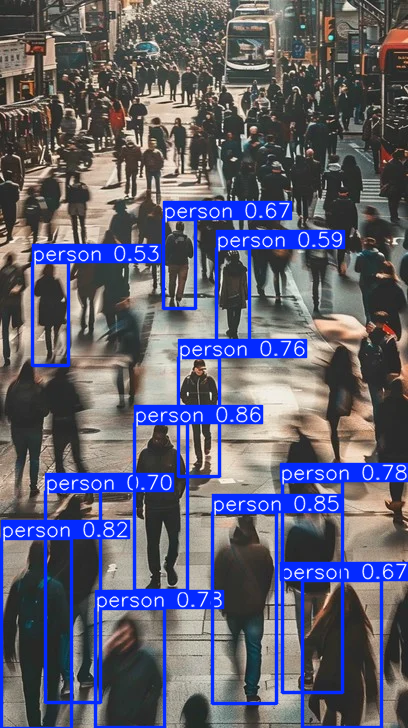

In [4]:


from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow


model = YOLO('yolov8n.pt')

results = model('/content/street.webp', conf=0.5)

for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]')

annotated = results[0].plot()
cv2_imshow(annotated)